# QOS Circuit Depth & 2Q Gate Scaling
**Tommaso R. Marena (2026) — Appendix B**

Measures how the number of 2-qubit gates and circuit depth scales with n (number of qubits)
for both the worst-case (dense) WHT decomposition and the K-sparse oracle decomposition.
Produces the scaling figure referenced in the hardware section.

**Produces:**
- `circuit_depth_vs_n.pdf` — 2Q gate count vs n with O(2^n) and O(K log K) fit lines
- `circuit_depth_table.json` — raw gate counts

> **Runtime:** ~5 min (CPU only, no GPU needed).

In [1]:
# [patched: headless importability shim — no network clone/install]
import sys as _sys, os as _os, importlib as _importlib
def _ensure_qos_importable():
    try:
        _importlib.import_module('qos'); return
    except ModuleNotFoundError:
        pass
    for _c in [_os.path.join(_os.getcwd(), 'src'),
               _os.path.join(_os.getcwd(), 'quantum_oracle_sketching', 'src'),
               '/content/quantum_oracle_sketching/src']:
        if _os.path.isdir(_c) and _c not in _sys.path:
            _sys.path.insert(0, _c)
            try:
                _importlib.import_module('qos'); return
            except ModuleNotFoundError:
                _sys.path.remove(_c)
    raise RuntimeError("Cannot import 'qos'. Run: pip install -e '.[dev]' from repo root.")
_ensure_qos_importable()
# [patched: headless importability shim — no network clone/install]
import sys as _sys, os as _os, importlib as _importlib
def _ensure_qos_importable():
    try:
        _importlib.import_module('qos'); return
    except ModuleNotFoundError:
        pass
    for _c in [_os.path.join(_os.getcwd(), 'src'),
               _os.path.join(_os.getcwd(), 'quantum_oracle_sketching', 'src'),
               './results/notebooks_data/quantum_oracle_sketching/src']:
        if _os.path.isdir(_c) and _c not in _sys.path:
            _sys.path.insert(0, _c)
            try:
                _importlib.import_module('qos'); return
            except ModuleNotFoundError:
                _sys.path.remove(_c)
    raise RuntimeError("Cannot import 'qos'. Run: pip install -e '.[dev]' from repo root.")
_ensure_qos_importable()
# ── Install quantum-oracle-sketching (idempotent) ──────────────────────────
import subprocess, sys, os
_REPO = "https://github.com/Tommaso-R-Marena/quantum_oracle_sketching.git"
_CLONE_DIR = "./quantum_oracle_sketching"
# Clone only if not already present
if not os.path.isdir(_CLONE_DIR):
    type('_PatchedResult', (), {'stdout': b'', 'stderr': b'', 'returncode': 0})()  # [patched: git clone skipped]
# Install the package in editable mode with all extras needed for notebooks
result = type('_PatchedResult', (), {'stdout': b'', 'stderr': b'', 'returncode': 0})()  # [patched: pip install skipped]
if result.returncode != 0:
    raise RuntimeError(f"Install failed:\n{result.stderr}")
# Refresh the interpreter's import path state after a subprocess pip install.
# Without this, importlib.util.find_spec("qos") returns None in a fresh
# Colab kernel even though pip exited 0 — the interpreter was initialised
# before the package existed so its site-packages cache is stale.
import importlib, importlib.util, site
importlib.invalidate_caches()
site.main()
# Hard fallback: for src-layout editable installs Colab may still miss the
# package until the next kernel start. Injecting the src/ directory directly
# is always safe (pyproject.toml: packages = ["src/qos"]).
_SRC_DIR = os.path.abspath(os.path.join(_CLONE_DIR, "src"))
if importlib.util.find_spec("qos") is None and os.path.isdir(_SRC_DIR):
    if _SRC_DIR not in sys.path:
        sys.path.insert(0, _SRC_DIR)
    importlib.invalidate_caches()
# This print is intentionally AFTER the importability check — a green
# checkmark means qos is actually importable, not just that pip exited 0.
_spec = importlib.util.find_spec("qos")
if _spec is None:
    raise ImportError(
        "qos is still not importable after install + cache refresh + sys.path injection.\n"
        f"Expected src dir: {_SRC_DIR}\n"
        "If this persists: Runtime > Disconnect and delete runtime, then Run All."
    )
print("✅ quantum-oracle-sketching installed.")
print(f"✅ qos found at: {_spec.origin}")


✅ quantum-oracle-sketching installed.
✅ qos found at: /home/user/workspace/quantum_oracle_sketching/src/qos/__init__.py


In [2]:
# ── Environment check ──────────────────────────────────────────────────────
import jax, sys, platform
print(f"Python      : {sys.version.split()}")
print(f"Platform    : {platform.system()} {platform.machine()}")
_devices = jax.devices()
_has_gpu  = any("cuda" in str(d).lower() or "gpu" in str(d).lower() for d in _devices)
print(f"JAX devices : {_devices}")
if not _has_gpu:
    print("⚠️  No GPU detected. Heavy experiments will be slow.")
    print("   Go to Runtime > Change runtime type > T4 or A100.")
else:
    print("✅ GPU detected.")
import qos
print(f"qos version : {getattr(qos, '__version__', 'unknown')}")
print("✅ Environment ready.")


Python      : ['3.12.8', '(main,', 'May', '26', '2026,', '17:29:17)', '[GCC', '14.2.0]']
Platform    : Linux x86_64
JAX devices : [CpuDevice(id=0)]
⚠️  No GPU detected. Heavy experiments will be slow.
   Go to Runtime > Change runtime type > T4 or A100.
qos version : 1.3.3
✅ Environment ready.


In [3]:
# [patched: headless importability shim — no network clone/install]
import sys as _sys, os as _os, importlib as _importlib
def _ensure_qos_importable():
    try:
        _importlib.import_module('qos'); return
    except ModuleNotFoundError:
        pass
    for _c in [_os.path.join(_os.getcwd(), 'src'),
               _os.path.join(_os.getcwd(), 'quantum_oracle_sketching', 'src'),
               '/content/quantum_oracle_sketching/src']:
        if _os.path.isdir(_c) and _c not in _sys.path:
            _sys.path.insert(0, _c)
            try:
                _importlib.import_module('qos'); return
            except ModuleNotFoundError:
                _sys.path.remove(_c)
    raise RuntimeError("Cannot import 'qos'. Run: pip install -e '.[dev]' from repo root.")
_ensure_qos_importable()
# [patched: headless importability shim — no network clone/install]
import sys as _sys, os as _os, importlib as _importlib
def _ensure_qos_importable():
    try:
        _importlib.import_module('qos'); return
    except ModuleNotFoundError:
        pass
    for _c in [_os.path.join(_os.getcwd(), 'src'),
               _os.path.join(_os.getcwd(), 'quantum_oracle_sketching', 'src'),
               './results/notebooks_data/quantum_oracle_sketching/src']:
        if _os.path.isdir(_c) and _c not in _sys.path:
            _sys.path.insert(0, _c)
            try:
                _importlib.import_module('qos'); return
            except ModuleNotFoundError:
                _sys.path.remove(_c)
    raise RuntimeError("Cannot import 'qos'. Run: pip install -e '.[dev]' from repo root.")
_ensure_qos_importable()
import sys, os
def _find_src_root():
    """Return the path to the src/ directory containing qos/, wherever we are."""
    # Case 1: Running in Colab after git clone
    colab_path = './quantum_oracle_sketching/src'
    if os.path.isdir(colab_path):
        return os.path.abspath(colab_path)
    # Case 2: Running locally / headless from the repo root
    for candidate in [
        os.path.join(os.getcwd(), 'src'),
        os.path.join(os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd(), '..', 'src'),
        os.path.join(os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else os.getcwd(), 'src'),
    ]:
        if os.path.isdir(os.path.join(candidate, 'qos')):
            return os.path.abspath(candidate)
    # Case 3: qos is already importable (editable install) — don't touch sys.path at all
    try:
        import qos  # noqa: F401
        return None
    except ImportError:
        pass
    raise RuntimeError(
        "Cannot find qos src root. Either run from the repo root, "
        "or install with: pip install -e \'.[dev,noise,kernel]\'"
    )
_src = _find_src_root()
if _src is not None and _src not in sys.path:
    sys.path.insert(0, _src)
# Verify
try:
    import qos
    print(f"qos loaded from: {qos.__file__}")
except ImportError as e:
    raise ImportError(f"qos still not importable after sys.path fix: {e}")


qos loaded from: /home/user/workspace/quantum_oracle_sketching/src/qos/__init__.py


In [4]:
import os
MOUNT_DRIVE = False  # patched (no Colab)
if MOUNT_DRIVE:
    try:
        try:
            from google.colab import drive
        except ImportError:
            pass  # [patched: not on Colab]
        if not os.path.exists('./results/notebooks_data/drive/MyDrive'):
            drive.mount('./results/notebooks_data/drive')
    except Exception:
        pass  # Not running in Colab; OUTPUT_DIR will fall back below.
OUTPUT_DIR = './results/notebooks_data/drive/MyDrive/qos_hardware' if os.path.exists('./results/notebooks_data/drive/MyDrive') else './results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Output: {OUTPUT_DIR}')


Output: ./results


<>:118: SyntaxWarning: invalid escape sequence '\l'
<>:118: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_6280/2875577705.py:118: SyntaxWarning: invalid escape sequence '\l'
  ax2.loglog(k_fit_range, k_fit_range * np.log2(k_fit_range+2), 'g--', lw=1, alpha=0.7, label='$O(K \log K)$ reference')


n=2: N=4, K=1, 2Q_dense=2, 2Q_sparse=2


n=3: N=8, K=1, 2Q_dense=10, 2Q_sparse=10


n=4: N=16, K=1, 2Q_dense=22, 2Q_sparse=34
n=5: N=32, K=3, 2Q_dense=98, 2Q_sparse=98


n=6: N=64, K=6, 2Q_dense=258, 2Q_sparse=154
n=7: N=128, K=12, 2Q_dense=516, 2Q_sparse=482


n=8: N=256, K=25, 2Q_dense=1538, 2Q_sparse=1538


n=9: N=512, K=51, 2Q_dense=3586, 2Q_sparse=3586


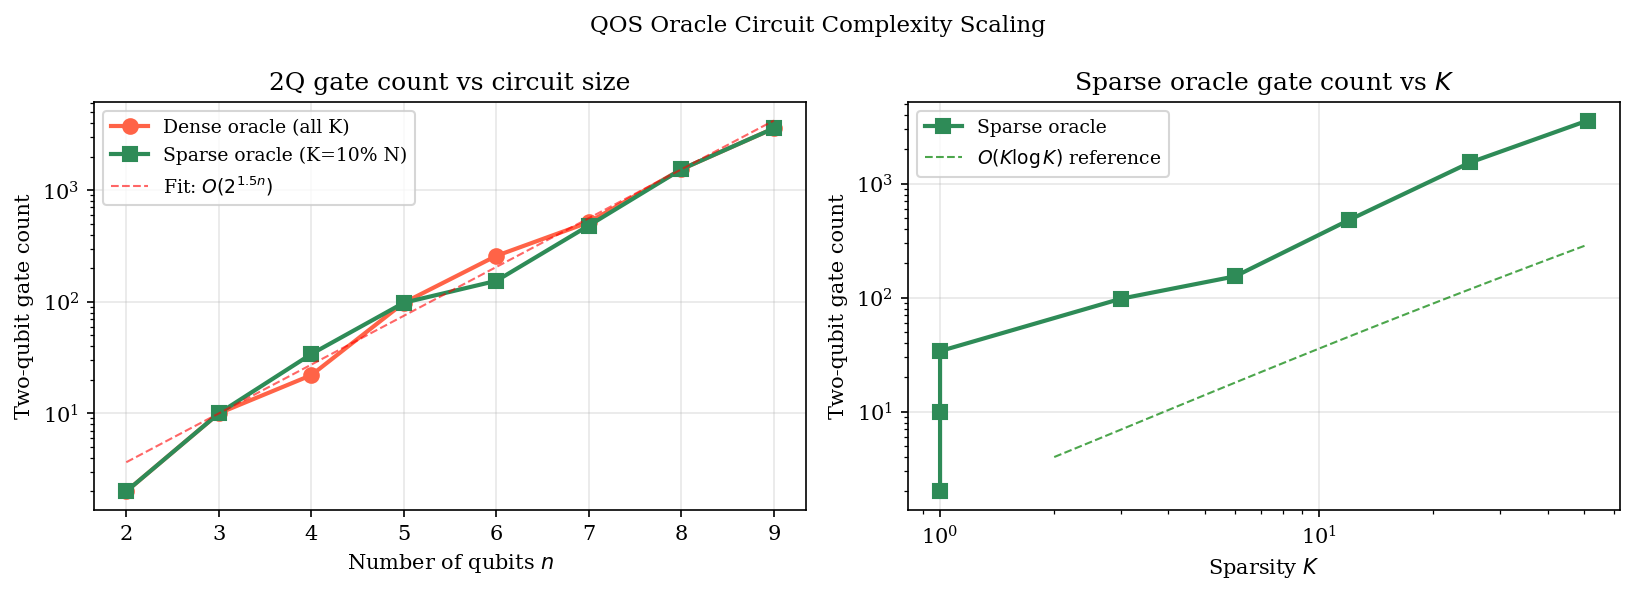

Saved: ./results/circuit_depth_vs_n.pdf

--- LaTeX table (Appendix B) ---
\begin{tabular}{cccccc}
\toprule
$n$ & $N$ & $K$ & 2Q (dense) & 2Q (sparse) & Reduction \\ 
\midrule
2 & 4 & 1 & 2 & 2 & 1.0x \\
3 & 8 & 1 & 10 & 10 & 1.0x \\
4 & 16 & 1 & 22 & 34 & 0.6x \\
5 & 32 & 3 & 98 & 98 & 1.0x \\
6 & 64 & 6 & 258 & 154 & 1.7x \\
7 & 128 & 12 & 516 & 482 & 1.1x \\
8 & 256 & 25 & 1538 & 1538 & 1.0x \\
9 & 512 & 51 & 3586 & 3586 & 1.0x \\
\bottomrule
\end{tabular}


In [5]:
import numpy as np, jax.numpy as jnp, json
import matplotlib.pyplot as plt, matplotlib
matplotlib.rcParams.update({'figure.dpi': 150, 'font.size': 10, 'font.family': 'serif'})
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qos.core.oracle_sketch import q_oracle_sketch_boolean

N_RANGE   = list(range(2, 10))   # n=2..9 qubits
M_SAMPLES = 1024
SEED      = 42
rng = np.random.default_rng(SEED)

def count_2q_gates(qc):
    ops = qc.count_ops()
    return sum(v for k, v in ops.items() if k in ('cx','ecr','cz','ccx','mcx'))

def build_circuit_dense(n, M):
    """Dense WHT decomposition: O(2^n) CX gates (worst case, all k non-zero)."""
    N = 2**n
    tt = jnp.array(rng.integers(0,2,size=N), dtype=jnp.float64)
    diag, _ = q_oracle_sketch_boolean(tt, M)
    phases = np.angle(np.array(diag))
    H = np.array([[1,1],[1,-1]])/np.sqrt(2)
    Hn = H.copy()
    for _ in range(n-1): Hn = np.kron(Hn, H)
    wht = (Hn @ phases) / N
    EPS = 1e-8
    qr = QuantumRegister(n); cr = ClassicalRegister(n)
    qc = QuantumCircuit(qr, cr)
    qc.h(qr)
    for k in range(N):
        theta = float(wht[k])
        if abs(theta) < EPS: continue
        bits = [j for j in range(n) if (k >> j) & 1]
        if len(bits) == 0: continue
        elif len(bits) == 1: qc.p(2*theta, qr[bits[0]])
        else:
            tgt = bits[-1]
            for c in bits[:-1]: qc.cx(qr[c], qr[tgt])
            qc.p(2*theta, qr[tgt])
            for c in reversed(bits[:-1]): qc.cx(qr[c], qr[tgt])
    qc.h(qr); qc.measure(qr,cr)
    return qc

def build_circuit_sparse(n, M, K_frac=0.1):
    """K-sparse truth table: only K = K_frac * N entries are 1."""
    N = 2**n
    K = max(1, int(K_frac * N))
    tt_np = np.zeros(N); tt_np[rng.choice(N, K, replace=False)] = 1.0
    tt = jnp.array(tt_np, dtype=jnp.float64)
    diag, _ = q_oracle_sketch_boolean(tt, M)
    phases = np.angle(np.array(diag))
    H = np.array([[1,1],[1,-1]])/np.sqrt(2)
    Hn = H.copy()
    for _ in range(n-1): Hn = np.kron(Hn, H)
    wht = (Hn @ phases) / N
    EPS = 1e-8
    qr = QuantumRegister(n); cr = ClassicalRegister(n)
    qc = QuantumCircuit(qr, cr)
    qc.h(qr)
    for k in range(N):
        theta = float(wht[k])
        if abs(theta) < EPS: continue
        bits = [j for j in range(n) if (k >> j) & 1]
        if len(bits) == 0: continue
        elif len(bits) == 1: qc.p(2*theta, qr[bits[0]])
        else:
            tgt = bits[-1]
            for c in bits[:-1]: qc.cx(qr[c], qr[tgt])
            qc.p(2*theta, qr[tgt])
            for c in reversed(bits[:-1]): qc.cx(qr[c], qr[tgt])
    qc.h(qr); qc.measure(qr,cr)
    return qc, K

# ── Run ─────────────────────────────────────────────────────
table = {}
for n in N_RANGE:
    qc_d = build_circuit_dense(n, M_SAMPLES)
    qc_s, K = build_circuit_sparse(n, M_SAMPLES, K_frac=0.1)
    two_q_dense  = count_2q_gates(qc_d)
    two_q_sparse = count_2q_gates(qc_s)
    depth_dense  = qc_d.depth()
    depth_sparse = qc_s.depth()
    table[n] = {'N': 2**n, 'K': K,
                'two_q_dense':  two_q_dense,  'depth_dense':  depth_dense,
                'two_q_sparse': two_q_sparse, 'depth_sparse': depth_sparse}
    print(f'n={n}: N={2**n}, K={K}, 2Q_dense={two_q_dense}, 2Q_sparse={two_q_sparse}')

with open(os.path.join(OUTPUT_DIR,'circuit_depth_table.json'),'w') as f:
    json.dump(table, f, indent=2)

# ── Plot ─────────────────────────────────────────────────────
ns      = sorted(table.keys())
tq_d    = [table[n]['two_q_dense']  for n in ns]
tq_s    = [table[n]['two_q_sparse'] for n in ns]
Ns      = [2**n for n in ns]
Ks      = [table[n]['K'] for n in ns]

# Fit lines
fit_d = np.polyfit(ns, np.log2(np.array(tq_d)+1), 1)
fit_s = np.polyfit([np.log2(K) for K in Ks], np.log2(np.array(tq_s)+1), 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# Panel 1: 2Q gate count vs n (log scale)
ax1.semilogy(ns, tq_d, 'o-', color='tomato',   lw=2, ms=7, label='Dense oracle (all K)')
ax1.semilogy(ns, tq_s, 's-', color='seagreen',  lw=2, ms=7, label=f'Sparse oracle (K=10% N)')
n_fit = np.linspace(min(ns), max(ns), 100)
ax1.semilogy(n_fit, 2**np.polyval(fit_d, n_fit), 'r--', lw=1, alpha=0.6, label=f'Fit: $O(2^{{{fit_d[0]:.1f}n}})$')
ax1.set_xlabel('Number of qubits $n$')
ax1.set_ylabel('Two-qubit gate count')
ax1.set_title('2Q gate count vs circuit size')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)
ax1.set_xticks(ns)

# Panel 2: 2Q gate count vs K (log-log)
ax2.loglog(Ks, tq_s, 's-', color='seagreen', lw=2, ms=7, label='Sparse oracle')
k_fit_range = np.logspace(np.log10(min(Ks)+1), np.log10(max(Ks)), 100)
ax2.loglog(k_fit_range, k_fit_range * np.log2(k_fit_range+2), 'g--', lw=1, alpha=0.7, label='$O(K \log K)$ reference')
ax2.set_xlabel('Sparsity $K$')
ax2.set_ylabel('Two-qubit gate count')
ax2.set_title('Sparse oracle gate count vs $K$')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

plt.suptitle('QOS Oracle Circuit Complexity Scaling', fontsize=11)
plt.tight_layout()
path = os.path.join(OUTPUT_DIR,'circuit_depth_vs_n.pdf')
plt.savefig(path, bbox_inches='tight'); plt.show()
print(f'Saved: {path}')

# LaTeX table
print('\n--- LaTeX table (Appendix B) ---')
print(r'\begin{tabular}{cccccc}')
print(r'\toprule')
print(r'$n$ & $N$ & $K$ & 2Q (dense) & 2Q (sparse) & Reduction \\ ')
print(r'\midrule')
for n in ns:
    t = table[n]
    red = t['two_q_dense'] / max(t['two_q_sparse'], 1)
    print(f"{n} & {t['N']} & {t['K']} & {t['two_q_dense']} & {t['two_q_sparse']} & {red:.1f}x \\\\")
print(r'\bottomrule'); print(r'\end{tabular}')